In [ ]:
import os
import re
import glob
import numpy as np
import pandas as pd
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib as mpl

# -------- SETTINGS --------
data_dir = r"C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results"
offset_step = 1
normalize = True
# --------------------------

def extract_strain(filename):
    base = os.path.basename(filename)

    if re.search(r'_0(\.0+)?\.csv$', base):
        return 0.0

    neg_match = re.search(r'neg[_\-]?(\d+\.?\d*)', base)
    if neg_match:
        return -float(neg_match.group(1))

    pos_match = re.search(r'pos[_\-]?(\d+\.?\d*)', base)
    if pos_match:
        return float(pos_match.group(1))

    raise ValueError(f"Could not extract strain from {filename}")

# Collect files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
files_with_strain = [(extract_strain(f), f) for f in csv_files]
files_with_strain.sort(key=lambda x: x[0])

# Extract strain values
strain_values = [s for s, _ in files_with_strain]

# Colormap normalization
norm = mpl.colors.Normalize(vmin=min(strain_values), vmax=max(strain_values))
cmap = mpl.cm.coolwarm

# -------- PLOTTING --------
fig, ax = plt.subplots(figsize=(8, 10))

for i, (strain, filepath) in enumerate(files_with_strain):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    x = df["Frequency (meV)"]
    y = df["DOS"]

    if normalize:
        y = y / np.max(y)

    y = y + i * offset_step

    ax.plot(x, y, color=cmap(norm(strain)), linewidth=1.5)

ax.set_xlabel("Energy (meV)", fontsize=12)
ax.set_ylabel("Normalized DOS (+ offset)", fontsize=12)
ax.set_title("Phonon DOS under Strain", fontsize=14)
ax.set_xlim(-3, 200)
# -------- COLORBAR --------
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Strain (%)", fontsize=12)

plt.tight_layout()
output_path = os.path.join(data_dir, "phonon_dos_strain.png")
plt.savefig(output_path, dpi=300)
plt.show()

In [3]:
import os
import re
import glob
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib import cm
from matplotlib.colors import Normalize, to_hex

pio.templates.default = "simple_white"

# -------- SETTINGS --------
data_dir = r"C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results"
offset_step = 1
normalize = True
# --------------------------

def extract_strain(filename):
    base = os.path.basename(filename)

    if re.search(r'_0(\.0+)?\.csv$', base):
        return 0.0

    neg_match = re.search(r'neg[_\-]?(\d+\.?\d*)', base)
    if neg_match:
        return -float(neg_match.group(1))

    pos_match = re.search(r'pos[_\-]?(\d+\.?\d*)', base)
    if pos_match:
        return float(pos_match.group(1))

    raise ValueError(f"Could not extract strain from {filename}")

# Collect files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
files_with_strain = [(extract_strain(f), f) for f in csv_files]
files_with_strain.sort(key=lambda x: x[0])

strain_values = [s for s, _ in files_with_strain]

norm = Normalize(vmin=min(strain_values), vmax=max(strain_values))
cmap = cm.get_cmap("coolwarm")

fig = go.Figure()

for i, (strain, filepath) in enumerate(files_with_strain):

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    x = df["Frequency (meV)"].values
    y = df["DOS"].values

    if normalize:
        y = y / np.max(y)

    y = y + i * offset_step

    color = to_hex(cmap(norm(strain)))

    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines',
        line=dict(color=color, width=2),
        name=f"{strain:+.2f} %"
    ))

fig.update_layout(
    title="Phonon DOS under Strain",
    xaxis_title="Energy (meV)",
    yaxis_title="Normalized DOS (+ offset)",
    height=800,
    legend=dict(
        title="Strain",
        orientation="v"
    )
)

fig.update_xaxes(range=[-3, 200])

output_path = os.path.join(data_dir, "phonon_dos_strain_interactive.html")
fig.write_html(output_path)

fig.show()

C:\Users\ech77\AppData\Local\Temp\ipykernel_14168\1199213030.py:43: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [4]:
import os
import re
import glob
import numpy as np
import pandas as pd

# -------- SETTINGS --------
data_dir = r"C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results"
normalize = True
# --------------------------

def extract_strain(filename):
    base = os.path.basename(filename)

    if re.search(r'_0(\.0+)?\.csv$', base):
        return 0.0

    neg_match = re.search(r'neg[_\-]?(\d+\.?\d*)', base)
    if neg_match:
        return -float(neg_match.group(1))

    pos_match = re.search(r'pos[_\-]?(\d+\.?\d*)', base)
    if pos_match:
        return float(pos_match.group(1))

    raise ValueError(f"Could not extract strain from {filename}")

# Collect and sort files
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
files_with_strain = [(extract_strain(f), f) for f in csv_files]
files_with_strain.sort(key=lambda x: x[0])

# Containers
strain_list = []
dos_list = []

for strain, filepath in files_with_strain:
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()

    energy = df["Frequency (meV)"].values
    dos = df["DOS"].values

    if normalize:
        dos = dos / np.max(dos)

    strain_list.append(strain)
    dos_list.append(dos)

# Convert to arrays
strains = np.array(strain_list)                     # shape (11,)
dos_array = np.vstack(dos_list)                     # shape (11, N)

print("Energy shape:", energy.shape)
print("Strains shape:", strains.shape)
print("DOS array shape:", dos_array.shape)

Energy shape: (303,)
Strains shape: (11,)
DOS array shape: (11, 303)


In [39]:
dos_minus_2p5 = dos_array[0]
dos_minus_2 = dos_array[1]
dos_minus_1p5 = dos_array[2]
dos_minus_1 = dos_array[3]
dos_minus_0p5 = dos_array[4]    
dos_zero = dos_array[5]
dos_plus_0p5 = dos_array[6]
dos_plus_1 = dos_array[7]
dos_plus_1p5 = dos_array[8]
dos_plus_2 = dos_array[9]
dos_plus_2p5 = dos_array[10]

In [ ]:
import hbn_pl.peaks as peaks
import hbn_pl.io as io

targets = [31, 66, 163, 192]
window = 4
fit_results = []

for t in targets:
    res = peaks.fit_peak_gaussian(energy, dos_minus_2p5, target=t, window=window)
    print(f"Fitted center for target {t} meV: {res['center']:.2f} ± {res['center_err']:.2f} meV")
    fit_results.append(res)

Fitted center for target 31 meV: 31.93 ± inf meV
Fitted center for target 66 meV: 69.17 ± 1.36 meV
Fitted center for target 163 meV: 162.50 ± 192163849.17 meV
Fitted center for target 192 meV: 188.25 ± 4.11 meV


C:\Users\ech77\OneDrive - University of Cambridge\2026\Code\hBN_PL\src\hbn_pl\peaks.py:51: OptimizeWarning:

Covariance of the parameters could not be estimated



In [95]:
output_path = os.path.join("C:\\Users\\ech77\\OneDrive - University of Cambridge\\2026\\Strain\\Theory results\\Peak fitting", "phonon_dos_strain_minus_2p5_fit_results.csv")
io.save_spectrum_and_interactive_html(output_path, energy, dos_minus_2p5, fit_results, targets, window=window)

Interactive figure saved to C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results\Peak fitting\phonon_dos_strain_minus_2p5_fit_results_interactive.html


Saved interactive plot: C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results\Peak fitting\phonon_dos_strain_minus_2p5_fit_results_interactive.html
Saved energy/intensity arrays: C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results\Peak fitting\phonon_dos_strain_minus_2p5_fit_results_energy.npz


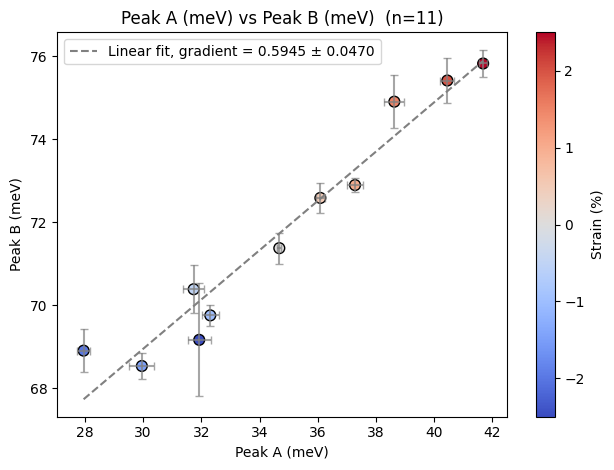

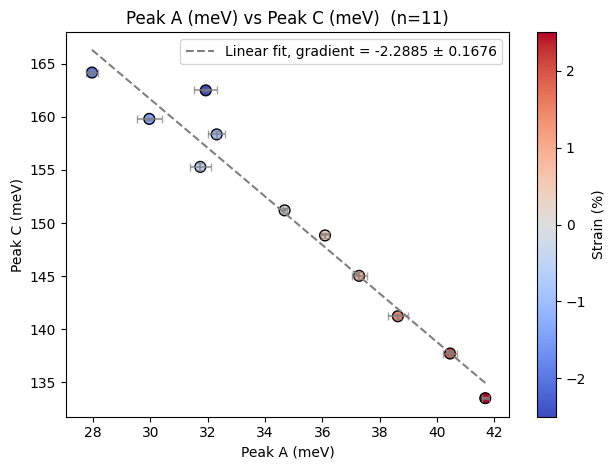

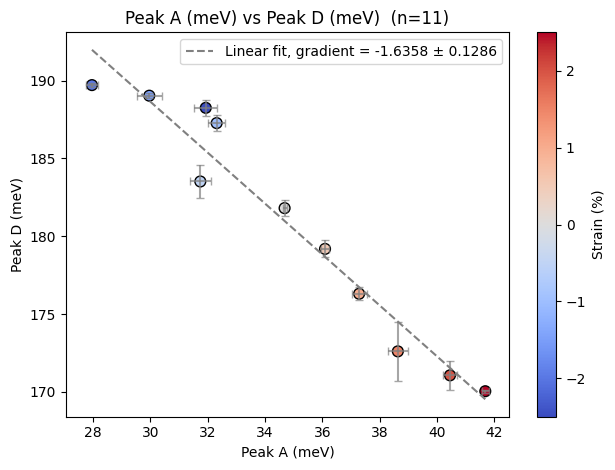

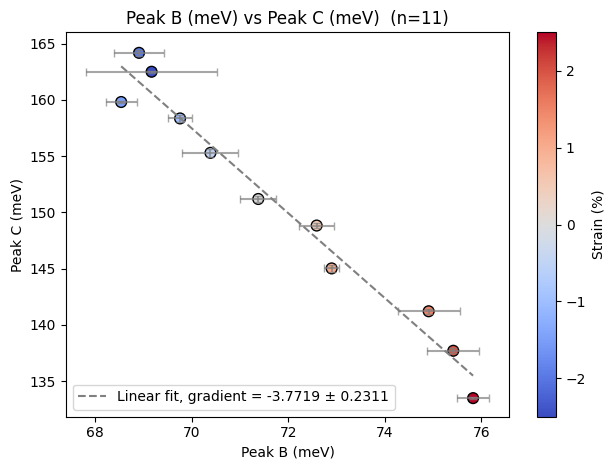

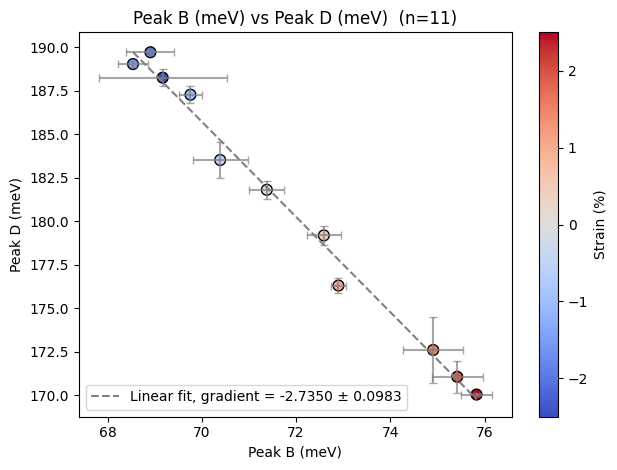

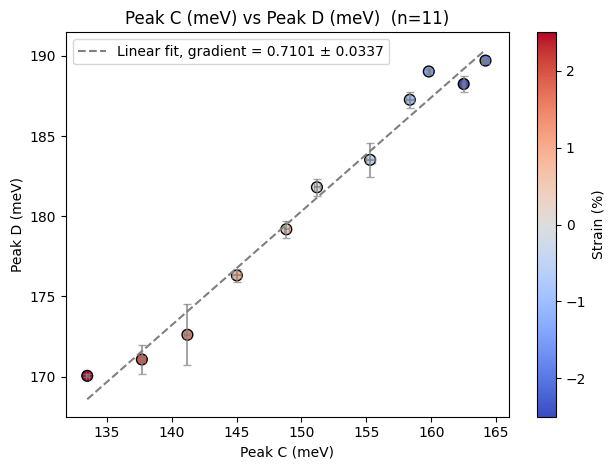

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np
import matplotlib as mpl

# Load data
file_path = r"C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results\Peak fitting\Peak fitting_results.csv"
df = pd.read_csv(file_path)

peaks = [
    ("Peak A (meV)", "Err A"),
    ("Peak B (meV)", "Err B"),
    ("Peak C (meV)", "Err C"),
    ("Peak D (meV)", "Err D"),
]

strain_col = "Strain"

# Set up consistent colormap normalization
norm = mpl.colors.Normalize(vmin=df[strain_col].min(),
                            vmax=df[strain_col].max())
cmap = mpl.cm.coolwarm

for (peak_x, err_x), (peak_y, err_y) in itertools.combinations(peaks, 2):

    sub = df[[peak_x, err_x, peak_y, err_y, strain_col]].dropna()

    if len(sub) < 2:
        continue

    plt.figure()

    # Scatter with strain colormap
    sc = plt.scatter(
        sub[peak_x],
        sub[peak_y],
        c=sub[strain_col],
        cmap=cmap,
        norm=norm,
        s=60,
        edgecolor='k'
    )

    # Error bars
    plt.errorbar(
        sub[peak_x],
        sub[peak_y],
        xerr=sub[err_x],
        yerr=sub[err_y],
        fmt='none',
        ecolor='gray',
        capsize=3,
        alpha=0.7
    )

    # Linear fit
    slope, intercept = np.polyfit(sub[peak_x], sub[peak_y], 1)
    # To get error in slope and intercept
    popt, pcov = np.polyfit(sub[peak_x], sub[peak_y], 1, cov=True)
    slope_err = np.sqrt(pcov[0,0])
    intercept_err = np.sqrt(pcov[1,1])

    # Plot fit line
    x_fit = np.linspace(sub[peak_x].min(), sub[peak_x].max(), 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, color='gray', linestyle='--', label=f'Linear fit, gradient = {slope:.4f} ± {slope_err:.4f}')

    cbar = plt.colorbar(sc)
    cbar.set_label("Strain (%)")

    plt.xlabel(peak_x)
    plt.ylabel(peak_y)
    plt.title(f"{peak_x} vs {peak_y}  (n={len(sub)})")
    plt.legend()
    plt.tight_layout()
    plt.show()

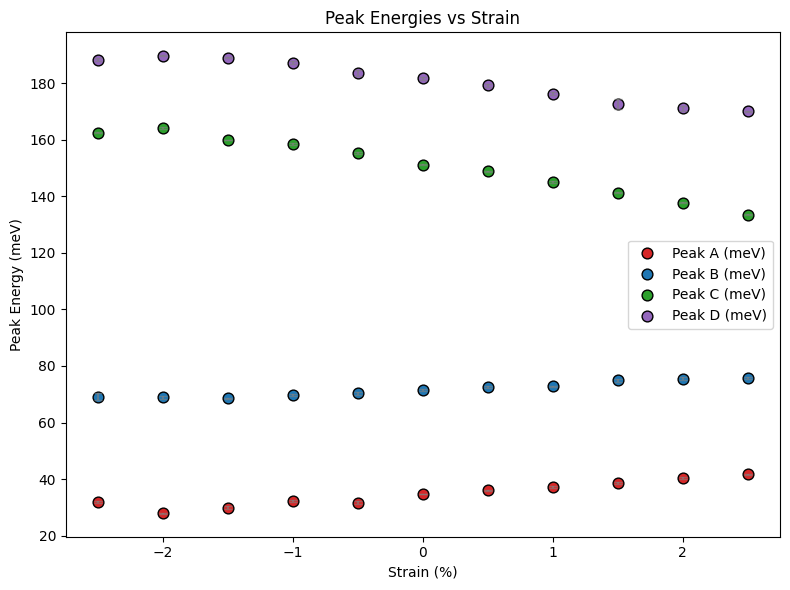

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
file_path = r"C:\Users\ech77\OneDrive - University of Cambridge\2026\Strain\Theory results\Peak fitting\Peak fitting_results.csv"
df = pd.read_csv(file_path)

strain_col = "Strain"
fit_colors = [
        "#D62728",  # red
        "#1F77B4",  # blue
        "#2CA02C",  # green
        "#9467BD"   # purple
    ]
peaks = [
    ("Peak A (meV)", "Err A", fit_colors[0]),
    ("Peak B (meV)", "Err B", fit_colors[1]),
    ("Peak C (meV)", "Err C", fit_colors[2]),
    ("Peak D (meV)", "Err D", fit_colors[3]),
]

plt.figure(figsize=(8, 6))

for peak_col, err_col, color in peaks:

    sub = df[[strain_col, peak_col, err_col]].dropna()
    
    # Scatter with fixed color
    plt.scatter(
        sub[strain_col],
        sub[peak_col],
        color=color,
        s=60,
        edgecolor='k',
        label=peak_col
    )

    # Error bars
    plt.errorbar(
        sub[strain_col],
        sub[peak_col],
        yerr=sub[err_col],
        fmt='none',
        ecolor='gray',
        alpha=0.6,
        capsize=3
    )

plt.xlabel("Strain (%)")
plt.ylabel("Peak Energy (meV)")
plt.title("Peak Energies vs Strain")
plt.legend()
plt.tight_layout()
plt.show()